# Tutorial - Understanding Image Embeddings through Pairwise Comparison
#### Author: Antonio Rueda-Toicen
#### Adapt to Keras: Joseph Hellerstein (eScience Institute, University of Washington)
#### [AI Service Center @ Hasso Plattner Institute](https://hpi.de/kisz/home.html)
**antonio.rueda.toicen 'at' hpi 'dot' de**


[![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)](http://creativecommons.org/licenses/by/4.0/)

This work is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).

## Overview

In this notebook, we explore the intuitions behind image embeddings by using them to compare image pairs.

We will use the output of a pretrained [neural network](https://en.wikipedia.org/wiki/Neural_network) and the [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) metric to measure how similar pairs of images are.

## Understanding Image Embeddings

Image embeddings are vectors that represent the features of an image. Embeddings encode aspects of the images, like color, shape, texture, and the presence of specific objects on 'high dimensional spaces'. These spaces are large vectors that are **very hard** for humans to visualize, although we can project them in two or three dimensions. We do this at the end of the notebook.

Embeddings are generated in many different ways. In the context of deep learning, embeddings are obtained from one of the layers of a trained neural network.

Embeddings are particularly powerful when they are generated by well-trained [Convolutional Neural Networks (CNNs)](https://en.wikipedia.org/wiki/Convolutional_neural_network). CNNs mimic parts of the human visual system by combining [image pyramids](https://en.wikipedia.org/wiki/Pyramid_(image_processing)) and [convolution filters (also known as image kernels)](https://setosa.io/ev/image-kernels/) in an architecture like the one shown below.

![](https://raw.githubusercontent.com/andandandand/image-dataset-curation/main/images/convolutional_network.png)

In this example, the embedding is produced at the stage labeled **"FLATTEN"** in the diagram.

It's important to understand that embeddings are only useful *if the network that produces them has been trained properly*. This means that the training data was well labeled and rich enough, and that the network achieved a good performance on [its validation set](https://en.wikipedia.org/wiki/Cross-validation_(statistics)). We will use [pre-trained networks](https://pytorch.org/vision/stable/models.html) on this example so that we can skip these training and validation steps.  

After a network has been trained to classify images, the embedding captures the visual patterns and labels assigned to the image, transforming it into a compressed form that can be used for various tasks beyond classification. Embeddings can be used for similarity evaluation and the generation of new images. We can also use them to match images to text. Image generators like [OpenAI's Dall-E](https://openai.com/research/dall-e) use embeddings of both text and images as starting points for the synthesis of new images.




## Setup

In [1]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
import tensorflow.keras.datasets as tfkds
import tensorflow_datasets as tfds
from tensorflow.keras.applications.vgg16 import VGG16
#from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
import importlib_resources
from typing import List, Callable

##  Apples, oranges, cars

Intuitively, which of these things are more similar?

* An apple vs another apple
* An apple vs an orange
* An apple vs a toy car

I mean this both in terms of appearance and meaning. Could we assign a score to their similarity? Let's start loading some images for this comparison.

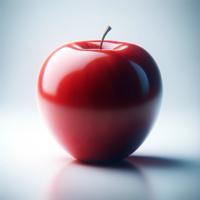

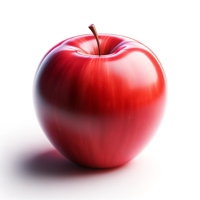

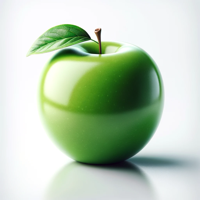

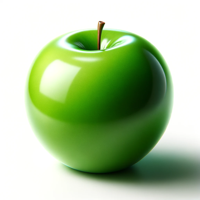

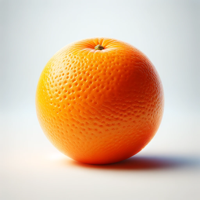

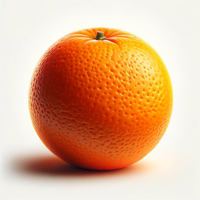

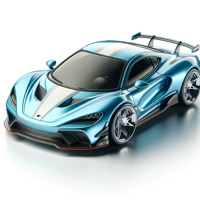

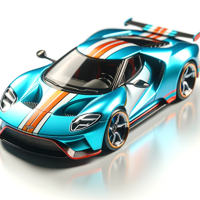

In [2]:

# Here's a simple way to get a list of images from urls

import skimage.io as io
from PIL import Image
from IPython.display import display

urls = ['https://github.com/andandandand/image-dataset-curation/blob/main/images/red_apple_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/red_apple_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/green_apple_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/green_apple_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/orange_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/orange_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/toy_car_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/toy_car_2.png?raw=true']

images = [Image.fromarray(io.imread(url)).convert('RGB')for url in urls]

printing_size = (200, 200)

for img in images:
    resized_img = img.resize(printing_size)
    display(resized_img);

## Pretrained neural network for embeddings

We use a pretrained [ResNet](https://en.wikipedia.org/wiki/Residual_neural_network) to create the vectors that embed our images.This network was trained to classify images in the [ImageNet dataset](https://www.image-net.org/). However, we are not using the ResNet for classification. For now, we only care about extracting the embeddings that it produces after it has been trained. These embeddings are very rich descriptions of appearance and meaning. The Imagenet dataset is huge, it has 14 million images, and the ResNet has been trained to achieve top performance in classifying its content. This is what makes the network such a powerful way to create image embeddings. Using a classification network that had been trained with less data would make our embeddings less rich and descriptive.

Even though you don't need to write this code from scratch (copy-pasting this bit into other notebooks is totally OK for our series of tutorials), it's interesting to look at it, specially if you have had a look at [PyTorch](https://pytorch.org/) before. We use hooks to extract the flattened representation of the image that is produced after all the convolution filters of the ResNet have been applied.

In [3]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image
import numpy as np
import requests
from io import BytesIO

# Load the pretrained model (embeddings only, no top classification layer)
model = ResNet50(weights="imagenet", include_top=False, pooling="avg")

# Function to extract embeddings from an image
def extract_embedding(image_path):
    if image_path.startswith("http"):
        response = requests.get(image_path)
        response.raise_for_status()  # raises an error if the download failed
        image = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))  # Keras models expect a fixed input size
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension
    image_array = preprocess_input(image_array)  # Applies ImageNet normalization
    embedding = model.predict(image_array, verbose=0)
    return embedding.squeeze()

# Example usage
embedding = extract_embedding(urls[0])
print(embedding.shape)

(2048,)


## Compare image pairs with the cosine similarity

The cosine similarity metric is computed as the cosine of the angle between these two vectors.

$$ \text{Cosine Similarity} = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}} $$



where:
- $ A $ and $ B $ are the feature vectors of the two images.
- $ A \cdot B $ is the dot product of vectors $ A $ and $ B $.
- $ \|A\| $ and $ \|B\| $ are the magnitudes (or norms) of vectors $ A $ and $ B $.

The result is a value between -1 and 1 that we can interpret easily:
- **1 indicates the vectors are identical:** 0 degree angle between the vectors, like a pair of vectors comprised of `vector_a = [1, 1, 1]`, `vector_b = [1, 1, 1]`.
- **0 indicates orthogonality: no similarity**, 90 degree angle between the vectors, the most extreme case of dissimilarity, like a pair of vectors comprised of `vector_a = [1, 1, 1]`, `vector_b = [0, 0, 0]`  .
- **-1 indicates signed opposite vectors:** 180 degree angle between the vectors, like a pair of vectors comprised of `vector_a = [5, 5, 5]`, `vector_b = [-5, -5, -5]`.

![](https://github.com/andandandand/image-dataset-curation/blob/main/images/orthogonal.png?raw=true)


Notice that the cosine similarity will output values between 0 and 1 when the input vectors are positive. This is how we most commonly use it to compare embeddings. It's advantageous that it's bounded between these two values for similar and  It's also important to know that there are many other ways that we can use to compute distance between vectors, with the [Euclidean distance](https://en.wikipedia.org/wiki/Euclidean_distance) being an alternative. The cosine similarity is strongly preferred over the Euclidean distance on many information-retrieval tasks as it is indifferent to the magnitude of the embedding vectors.

We can implement the cosine similarity using Numpy and the following code:


In [4]:
import numpy as np
import skimage.io as io
from numpy import dot
from numpy.linalg import norm

def cosine_similarity(a, b):
  return dot(a, b)/(norm(a)*norm(b))

vec1 = np.array([1, 2, 3])
vec2 = np.array([2, 4, 6])


# Think about this, why are these vectors aligned?
similarity = cosine_similarity(vec1, vec2)
print(similarity)


1.0


In [5]:
# Defining two orthogonal vectors
vecX = np.array([1, 0, 0])
vecY = np.array([0, 1, 0])

# Calculating their cosine similarity
similarity = cosine_similarity(vecX, vecY)
similarity

np.float64(0.0)

In [6]:
import matplotlib.pyplot as plt
import skimage.io as io

def print_cosine_similarity(embedding_a, embedding_b):
  cos = cosine_similarity(embedding_a, embedding_b)
  # We do this to limit the number of decimals in the printed output
  result = f'Cosine similarity = {cos:.2f}'
  print(result)

def show_pair(imag_a, imag_b):
  plt.subplot(121)
  plt.imshow(np.array(imag_a))
  plt.axis("off")

  plt.subplot(122)
  plt.imshow(np.array(imag_b))
  plt.axis("off")

In [7]:
vec_1 = extract_embedding(urls[0])
vec_2 = extract_embedding(urls[1])

In [8]:
print_cosine_similarity(vec_1, vec_2)

Cosine similarity = 0.84


In [9]:
embeddings = [extract_embedding(url) for url in urls]

In [10]:
# Each of our embeddings has 512 dimensions
embeddings[0].shape

(2048,)

## A slider to compare image pairs

Humans have a hard time understanding high-dimensional data. It's a bit counterintuitive why vectors that encode both similar semantics and similar appearance in high-dimensional spaces seem to be aligned. It's easier to experiment with this to convince yourself that it works.  

Here's the exploration that you should focus on in this notebook.

Play with the slider values and think about:

* Which image pairs are most similar?
* Which image pairs are most dissimilar?


We'll use these key intuitions about image pairs and the cosine similarity in the following notebooks.  

Cosine similarity = 0.44


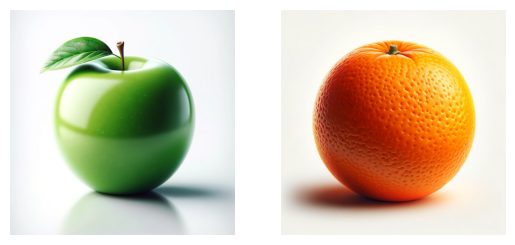

In [11]:
# @title {run:'auto'}


slider_1 = 2  # @param {type: "slider", min: 0, max: 6}

slider_2 = 5  # @param {type: "slider", min: 0, max: 6}
print_cosine_similarity(embeddings[slider_1], embeddings[slider_2])
show_pair(images[slider_1], images[slider_2])

## Preview for what's next: visualizing a projection of the embedding space in 3 dimensions

Humans cannot visualize vectors of more than four dimensions. Those are the x, y, and z axes combined with evolution in time.

In order for us to easily visualize a 512-dimensional embedding space, like the one that we created for our images of apples, oranges, and cars, we need to compress the information in the original space to two or three dimensions. For this we can use techniques like [Principal Component Analysis (PCA)](https://en.wikipedia.org/wiki/Principal_component_analysis) and [UMAP](https://umap-learn.readthedocs.io/en/latest/). These projections lose the detail that we can obtain from pairwise comparison through the cosine similarity or the Euclidean distance, but are often useful when we are dealing with larger datasets. Try running the code below and take a look at its output. You will find a more in-depth explanation of TensorBoard's Project [in tutorial](https://github.com/KISZ-BB/image-dataset-curation-workshops/blob/main/notebooks/Tutorial_Part5_Visualizing_Image_Embeddings_with_Tensorboard.ipynb), where we will use it to visualize a bigger dataset, one of public domain artworks that we have scraped from the internet.

In [12]:
import os
import numpy as np
import tensorflow as tf
from tensorboard.plugins import projector
from PIL import Image

# Directory for TensorBoard logs
log_dir = 'runs/paintings_embeddings_experiment'
os.makedirs(log_dir, exist_ok=True)

# Define the size for the thumbnails
thumbnail_size = (32, 32)

# Resize images and collect them as a list
thumbnail_images = [img.resize(thumbnail_size).convert("RGB") for img in images]

# --- Build a single "sprite" image containing all thumbnails ---
def create_sprite(images, thumbnail_size):
    num_images = len(images)
    grid_cols = int(np.ceil(np.sqrt(num_images)))
    grid_rows = int(np.ceil(num_images / grid_cols))

    sprite_width = grid_cols * thumbnail_size[0]
    sprite_height = grid_rows * thumbnail_size[1]
    sprite_image = Image.new('RGB', (sprite_width, sprite_height), (255, 255, 255))

    for idx, img in enumerate(images):
        row = idx // grid_cols
        col = idx % grid_cols
        x = col * thumbnail_size[0]
        y = row * thumbnail_size[1]
        sprite_image.paste(img, (x, y))

    return sprite_image

sprite_image = create_sprite(thumbnail_images, thumbnail_size)
sprite_path = os.path.join(log_dir, 'sprite.png')
sprite_image.save(sprite_path)

# --- Convert embeddings to a NumPy array ---
embeddings_array = np.stack([np.asarray(emb) for emb in embeddings])

# --- Save embeddings as a TF checkpoint variable ---
embedding_var = tf.Variable(embeddings_array, name='paintings_embeddings')
checkpoint = tf.train.Checkpoint(embedding=embedding_var)
checkpoint.save(os.path.join(log_dir, 'embedding.ckpt'))

# --- Optional: write metadata (labels) file, one line per embedding ---
metadata_path = os.path.join(log_dir, 'metadata.tsv')
with open(metadata_path, 'w') as f:
    for i in range(len(embeddings_array)):
        f.write(f"{i}\n")  # replace with actual labels if you have them

# --- Configure the Projector ---
config = projector.ProjectorConfig()
embedding_config = config.embeddings.add()
embedding_config.tensor_name = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
embedding_config.metadata_path = 'metadata.tsv'
embedding_config.sprite.image_path = 'sprite.png'
embedding_config.sprite.single_image_dim.extend(thumbnail_size)

projector.visualize_embeddings(log_dir, config)

print(f"Run: tensorboard --logdir {log_dir}")

Run: tensorboard --logdir runs/paintings_embeddings_experiment


In [13]:
# Run tensorboard to see the visualization
!tensorboard --logdir runs/paintings_embeddings_experiment

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.21.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C
